<a href="https://colab.research.google.com/github/nanaaries313/Portfolio/blob/main/Ensembles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Week 4: Ensembles (Bagging and Adaboost) + Tuning in Caret**

This script covers two different areas in four sections:
 1. Ensemble Models for Iris Data
 2. Boosting for Glass Data
 3. Parameter Tuning in Caret - Glass Data
 4. Boosting/bagging for Glass Data (lecture notes example)

 1,2 and 4 are on this week's material. 3 covers previous two weeks (DTs, KNN, evaluating error) and will be helpful for the next homework. I'll go through them in order and skip the last section if needed (results discussed briefly on Wednesday).

 Load all the packages we are going to use

Fix for new Mac Os when using adabag: rgl.useNULL, rgl

In [3]:
pkgs <- c("rpart", "rpart.plot", "adabag", "caret", "ggplot2")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

In [4]:
library(rpart)
library(rpart.plot)
library(adabag)
library(caret)
library(ggplot2)

## **Ensemble Models for Iris Data**

There are several "built-in" datasets in R, including the iris data, which we will use again when talking about clustering

50 observations for each species


In [5]:
View(iris)

Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
<dbl>,<dbl>,<dbl>,<dbl>,<fct>
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa
4.6,3.4,1.4,0.3,setosa
5.0,3.4,1.5,0.2,setosa
4.4,2.9,1.4,0.2,setosa



When we talk about random training and test datasets, we're talking about randomly sampling to determine which data points are in each set. This is easily done using the sample() function.

The iris data has 150 data points. Let's pick 100 at random.

In [6]:
set.seed(3) # Try some different seed values at home - you will
            # get some strange results

Some random processes such as sample() will results in different numbers every time. By setting as seed, you make sure that the sequence of 'random' numbers generated by R is always the same. 3 is the starting point for the random number sequence

Determine the indices of the training data points. All the others are the test data.

In [7]:
train = sample(1:150,size = 100, replace =FALSE) #random sampling

 Note that we really only need the indices, but if you really wanted the training and test data in data frames, it would be:

In [8]:
iris.train = iris[train,]
iris.test = iris[-train,]
View(iris.train)
View(iris.test)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
5,5.0,3.6,1.4,0.2,setosa
140,6.9,3.1,5.4,2.1,virginica
36,5.0,3.2,1.2,0.2,setosa
107,4.9,2.5,4.5,1.7,virginica
136,7.7,3.0,6.1,2.3,virginica
20,5.1,3.8,1.5,0.3,setosa
74,6.1,2.8,4.7,1.2,versicolor
48,4.6,3.2,1.4,0.2,setosa
104,6.3,2.9,5.6,1.8,virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
13,4.8,3.0,1.4,0.1,setosa
14,4.3,3.0,1.1,0.1,setosa
21,5.4,3.4,1.7,0.2,setosa
23,4.6,3.6,1.0,0.2,setosa
24,5.1,3.3,1.7,0.5,setosa
25,4.8,3.4,1.9,0.2,setosa
30,4.7,3.2,1.6,0.2,setosa
31,4.8,3.1,1.6,0.2,setosa


I'm never actually going to use "iris.train" and "iris.test" directly. Just the vector "train" of indices.

Before creating ensemble models, I'm going to create a simple tree as a benchmark and note the error rate

In [9]:
tree = rpart(Species~.,
             data = iris[train,])
CM = table(predict(tree,iris[-train,],type="class"),
           iris[-train,]$Species)
CM
1-(CM[1,1]+CM[2,2]+CM[3,3])/sum(CM)

            
             setosa versicolor virginica
  setosa         17          0         0
  versicolor      0         17         2
  virginica       0          0        14

[1] 0.04

We see that a simple tree does very well here. Can we improve?

Try an ensemble of boosted trees

In [10]:
n = 20 # Number of boosting/bagging iterations

"boosting" is a function in the adabag packages

In [11]:
boosted.trees = boosting(Species~.,
                         data = iris[train,],
                         mfinal = n)

mfinal = n: how many individual models (typically decision trees) will be built and combined to form the final ensemble.

"errorevol" is also a function in the adabag package

In [12]:
test.error = errorevol(boosted.trees,iris[-train,]) # test data are all the data point NOT in train
train.error = errorevol(boosted.trees,iris[train,])

errorevol() shows how the error changes over boosting iterations on unseen data

"plot.errorevol" is another function in adabag - easy but not great

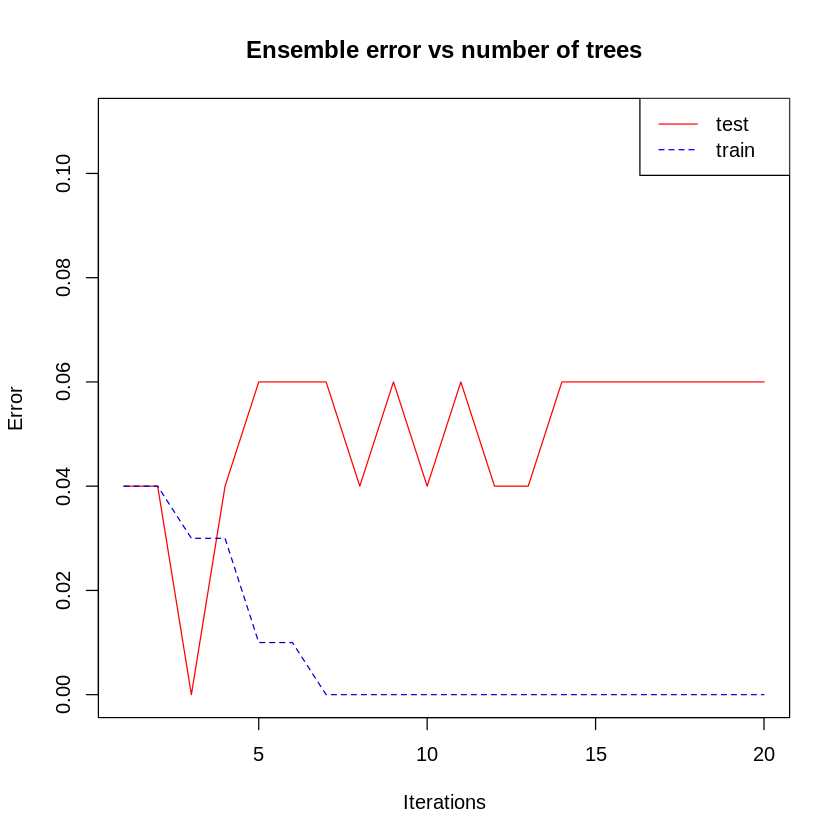

In [13]:
plot.errorevol(test.error,train.error)

Training error converges quickly to zero, but the ensemble may or may not be better on the test data. (Note that in this case the test error will go down again if you increase the number of iterations even further. Try it.)

The other main function in the adabag packages is "bagging"

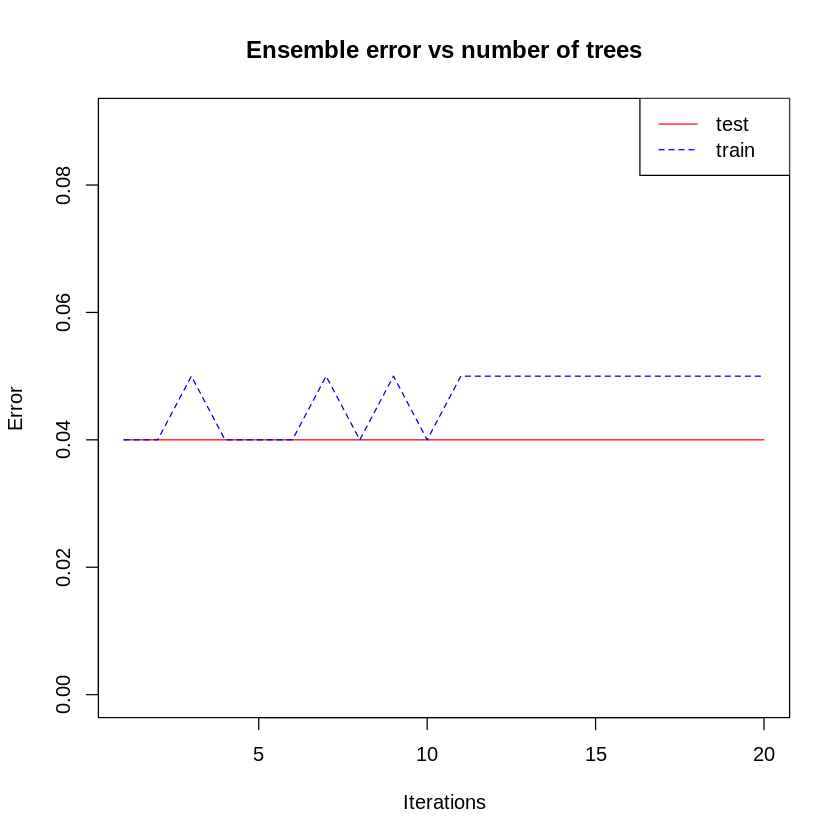

In [14]:
bagged.trees = bagging(Species~.,
                       data = iris[train,],
                       mfinal = n)
test.error = errorevol(bagged.trees,iris[-train,])
train.error = errorevol(bagged.trees,iris[train,])
plot.errorevol(test.error,train.error)

The ensemble models don't seem to be able to improve performance,but at least the bagging does no harm! (It is possibe that you can get improvements with more iterations.) There is not much variance to begin with, so bagging doesn't do anything

Improvements are more likely for more complex classification problems. What does complex mean?

In this case a simple DT does a good job (only 4% error on the training data).

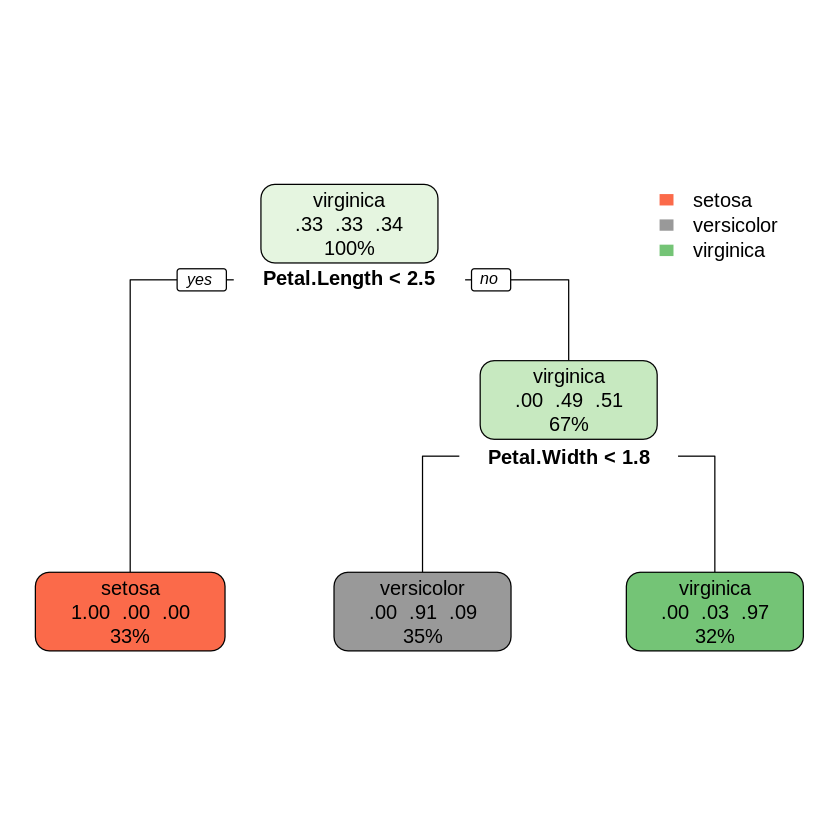

In [15]:
rpart.plot(tree)

Such a simple tree being 96% accurate for a 3 class-value problem means that this is an easy classification problem. No need for complex ensembles.


## **Boosting the Glass Data**

Read in the glass data: crime scene data. Look at glass compositions to find out where these glasses come from

In [21]:
glass = read.csv("glass.csv", stringsAsFactors = TRUE)
View(glass)

RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1.51793,12.79,3.50,1.12,73.03,0.64,8.77,0.00,0.00,'build wind float'
1.51643,12.16,3.52,1.35,72.89,0.57,8.53,0.00,0.00,'vehic wind float'
1.51793,13.21,3.48,1.41,72.64,0.59,8.43,0.00,0.00,'build wind float'
1.51299,14.40,1.74,1.54,74.55,0.00,7.59,0.00,0.00,tableware
1.53393,12.30,0.00,1.00,70.16,0.12,16.19,0.00,0.24,'build wind non-float'
1.51655,12.75,2.85,1.44,73.27,0.57,8.79,0.11,0.22,'build wind non-float'
1.51779,13.64,3.65,0.65,73.00,0.06,8.93,0.00,0.00,'vehic wind float'
1.51837,13.14,2.84,1.28,72.85,0.55,9.07,0.00,0.00,'build wind float'
1.51545,14.14,0.00,2.68,73.39,0.08,9.07,0.61,0.05,headlamps


Create a training/test sample

In [22]:
m = length(glass$Type) # Number of data points
set.seed(1)
train = sample(1:m,
               size = as.integer(m*0.8),
               replace =FALSE)

# Simple tree as a benchmark
tree = rpart(Type~.,
             data = glass[train,],
             control=rpart.control(cp = 0.001)) # This complexity
                                                # parameter value is
                                                # explained below.
CM=table(glass[-train,]$Type,predict(tree,glass[-train,],type="class"))
error=1-(CM[1,1]+CM[2,2]+CM[3,3]+CM[4,4]+CM[5,5]+CM[6,6])/sum(CM)
error

[1] 0.4651163

This is clearly a more difficult classification problem with a high error rate. Hopefully, ensembles can help!

Boosted tree ensemble

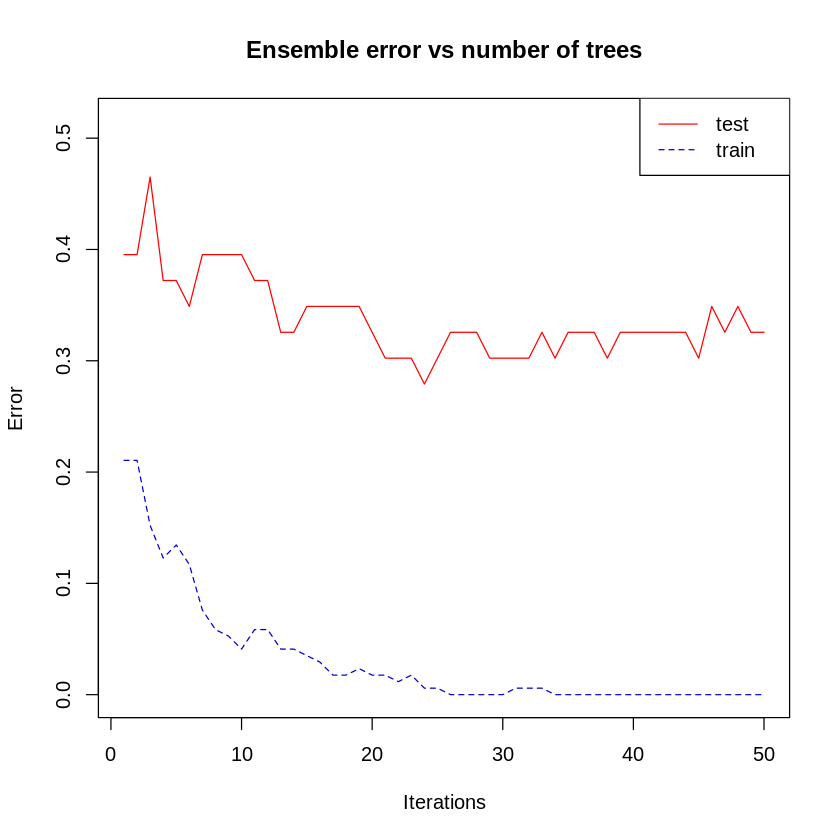

In [25]:
boosted.trees = boosting(Type~.,
                         data = glass[train,],
                         mfinal = 50,
                         control=rpart.control(cp = 0.001))
test.error = errorevol(boosted.trees,glass[-train,])
train.error = errorevol(boosted.trees,glass[train,])
plot.errorevol(test.error,train.error,)

The simple tree has error rate of 46.5%. The boosting is helping, and even more boosting iterations may help more (try increasing the iteration to 500 (set mfinal = 500)).

Training error for boosting tends to drop down to 0 drastically

## **Parameter Tuning in Caret - Glass Data**

In this section we are going to look at two things:
  
a) how to use the train function to tune parameters (rpart and knn3), and

b) how to use the train function to evaluate error.

We will continue to use the glass data.

Start by evaluating the amount of variance for training a DT

Before doing anything, need to see if we can use independent test (when the data is large)

[1] 0.7352941 0.6911765 0.7205882 0.6911765 0.7058824 0.7500000 0.6764706
 [8] 0.7205882 0.7205882 0.7205882 0.6617647 0.6764706 0.7058824 0.6764706
[15] 0.6176471 0.7205882 0.7647059 0.5588235 0.7058824 0.7352941 0.6323529
[22] 0.6323529 0.6764706 0.7205882 0.6029412 0.6764706 0.7500000 0.5588235
[29] 0.7647059 0.6764706 0.6617647 0.7058824 0.6764706 0.7647059 0.7058824
[36] 0.6470588 0.6470588 0.6470588 0.7058824 0.6911765 0.6617647 0.7058824
[43] 0.6470588 0.6911765 0.6911765 0.6764706 0.7058824 0.7058824 0.5588235
[50] 0.6911765

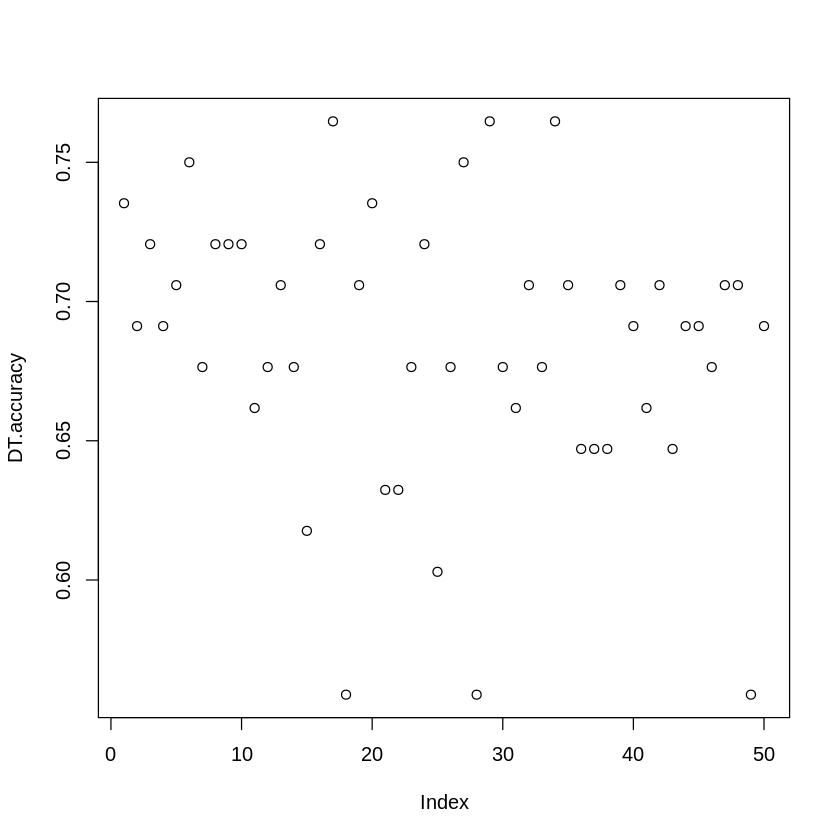

In [40]:
DT.accuracy = NULL
for(i in 1:50) {
  # I'm using the createDataPartition() function from caret, but I
  # could have used the sample() function as above.
  trainIndex = createDataPartition(glass$Type,p=.67,list=FALSE,times=1)
  glassTrain = glass[trainIndex,]
  glassTest = glass[-trainIndex,]
  DTmodel = rpart(Type ~ . , data=glassTrain)
  prediction = predict(DTmodel,glassTest,type="class")
  DT.accuracy[i] = confusionMatrix(prediction,glassTest$Type)$overall[1]
}
DT.accuracy
plot(DT.accuracy)

In [41]:
sqrt(var(DT.accuracy))

[1] 0.04883358

Based on the high variance, spliting the data into test and train is probably not the best idea. The data is not huge enough for independent testing

We would want to train and tune a model on all the data

We can specify a tune grid in the train() function; that is a set of values to try for the tuning parameters.

Since the data is small, I'm going to use the 0.632-bootstrap (at least until I know better).

In [28]:
DTmodel.tuned = train(glass[,1:9], glass$Type,
                      method="rpart",
                      trControl = trainControl(method="boot632"),
                      tuneGrid = expand.grid(cp = c(0.001, 0.005,
                                                    0.01, 0.05, 0.1)))

Recommend to take the default cp (0.01) and go right and left of it to check which one the best

I can output the model

In [29]:
DTmodel.tuned

CART 

214 samples
  9 predictor
  6 classes: ''build wind float'', ''build wind non-float'', ''vehic wind float'', 'containers', 'headlamps', 'tableware' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 214, 214, 214, 214, 214, 214, ... 
Resampling results across tuning parameters:

  cp     Accuracy   Kappa    
  0.001  0.6969389  0.5838277
  0.005  0.6975844  0.5847770
  0.010  0.7033203  0.5924038
  0.050  0.6676401  0.5278716
  0.100  0.6215472  0.4496443

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.01.

And I can plot the performance (here accuracy) as a function of the tuning parameters

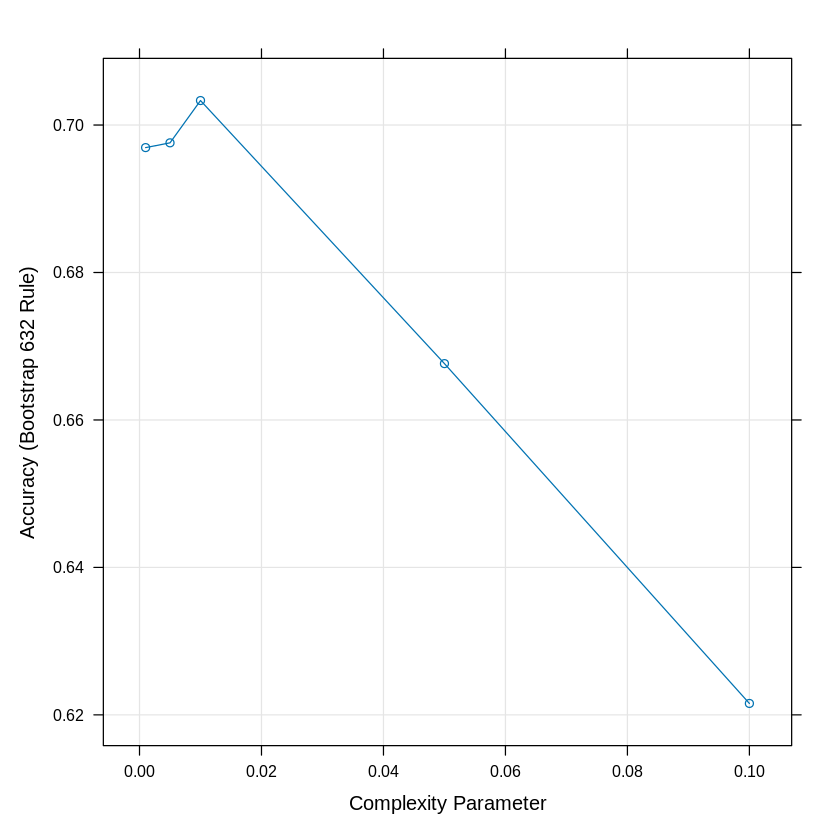

In [30]:
plot(DTmodel.tuned)

A low value of cp seems to be the way to go. Should we add zero?

CART 

214 samples
  9 predictor
  6 classes: ''build wind float'', ''build wind non-float'', ''vehic wind float'', 'containers', 'headlamps', 'tableware' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 214, 214, 214, 214, 214, 214, ... 
Resampling results across tuning parameters:

  cp     Accuracy   Kappa    
  0.000  0.7042817  0.5983610
  0.001  0.7042817  0.5983610
  0.005  0.7046100  0.5986913
  0.010  0.7060450  0.6005788
  0.050  0.6656421  0.5318195
  0.100  0.6166053  0.4484610

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.01.

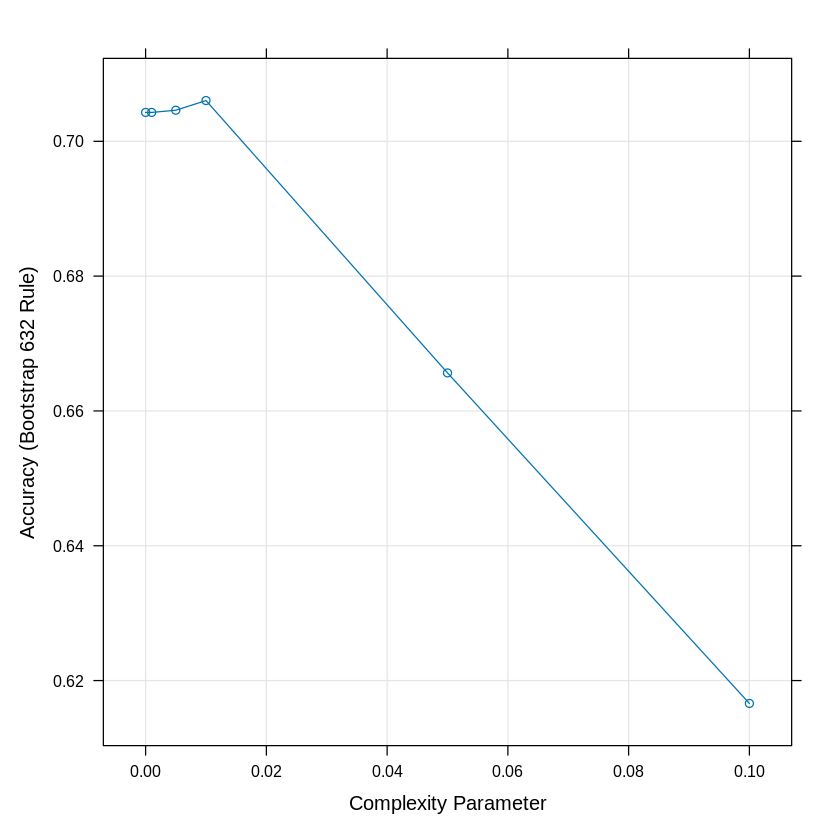

In [31]:
DTmodel.tuned.2 = train(glass[,1:9], glass$Type,
                        method="rpart",
                        trControl = trainControl(method="boot632"),
                        tuneGrid = expand.grid(cp = c(0,0.001, 0.005,
                                                      0.01, 0.05, 0.1)))
DTmodel.tuned.2
plot(DTmodel.tuned.2)

Any value cp < 0.01 seems to be best; that is, we want an unpruned DT. What does it tell us that an unpruned tree is the best?


Let's evaluate the variance for KNN on this dataset

In [32]:
KNN.accuracy = NULL
for(i in 1:50) {
  trainIndex = createDataPartition(glass$Type,p=.67,list=FALSE,times=1)
  glassTrain = glass[trainIndex,]
  glassTest = glass[-trainIndex,]
  KNNmodel = knn3(Type ~ . , data=glassTrain)
  prediction = predict(KNNmodel,glassTest,type="class")
  KNN.accuracy[i] = confusionMatrix(prediction,glassTest$Type)$overall[1]
}
KNN.accuracy
sqrt(var(KNN.accuracy))

[1] 0.6764706 0.6911765 0.6617647 0.7205882 0.6029412 0.6764706 0.6764706
 [8] 0.7500000 0.6176471 0.6911765 0.6029412 0.6911765 0.7352941 0.6470588
[15] 0.7205882 0.6764706 0.6617647 0.7205882 0.6911765 0.7205882 0.6470588
[22] 0.5735294 0.6764706 0.6029412 0.6323529 0.6911765 0.7205882 0.7647059
[29] 0.6764706 0.6176471 0.6911765 0.6617647 0.6617647 0.6470588 0.6323529
[36] 0.6029412 0.6617647 0.6323529 0.7058824 0.6470588 0.7205882 0.6617647
[43] 0.7500000 0.6617647 0.7205882 0.6470588 0.6029412 0.7352941 0.6323529
[50] 0.6323529

[1] 0.0451451

The variance is again high. I suspect we're better off using all the data to train a model and then use resampling to evaluate that model

If we tune on just the train data (2/3 of the data)

Split the data into a test and training dataset (2/3 train, 1/3 test)

k-Nearest Neighbors 

146 samples
  9 predictor
  6 classes: ''build wind float'', ''build wind non-float'', ''vehic wind float'', 'containers', 'headlamps', 'tableware' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 146, 146, 146, 146, 146, 146, ... 
Resampling results across tuning parameters:

  k  Accuracy   Kappa    
  1  0.7702744  0.6873730
  3  0.6698480  0.5501672
  5  0.6547133  0.5252659
  7  0.6343334  0.4926525
  9  0.6024816  0.4431246

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 1.

k-Nearest Neighbors 

214 samples
  9 predictor
  6 classes: ''build wind float'', ''build wind non-float'', ''vehic wind float'', 'containers', 'headlamps', 'tableware' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 214, 214, 214, 214, 214, 214, ... 
Resampling results across tuning parameters:

  k  Accuracy   Kappa    
  1  0.8201500  0.7572374
  3  0.7258845  0.6268353
  5  0.6886212  0.5736197
  7  0.6780950  0.5562569
  9  0.6568968  0.5238076

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 1.

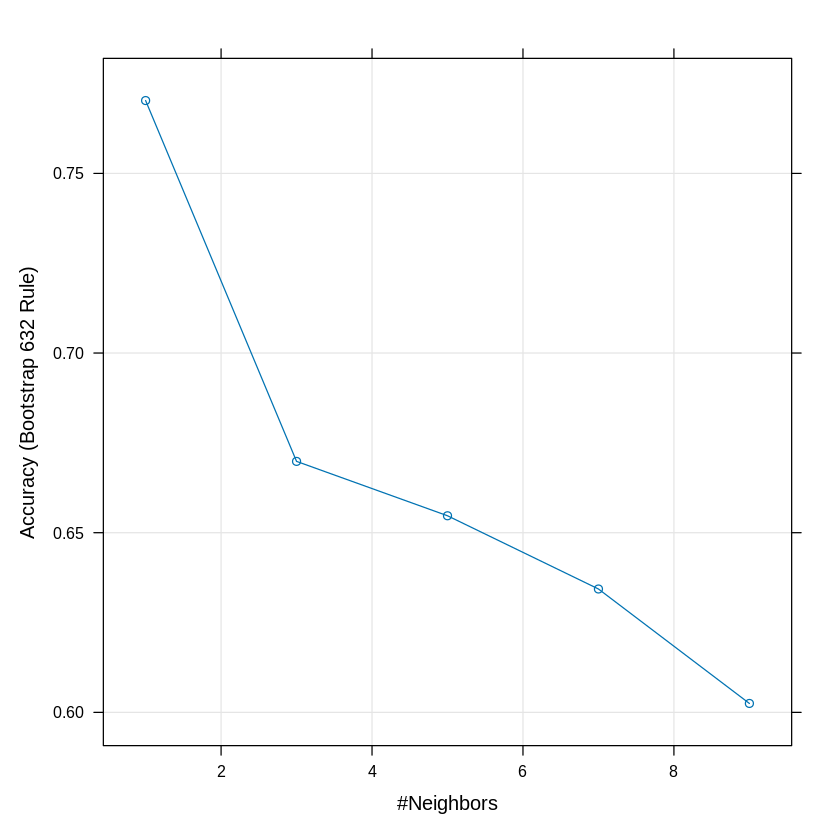

[1] 0.82015

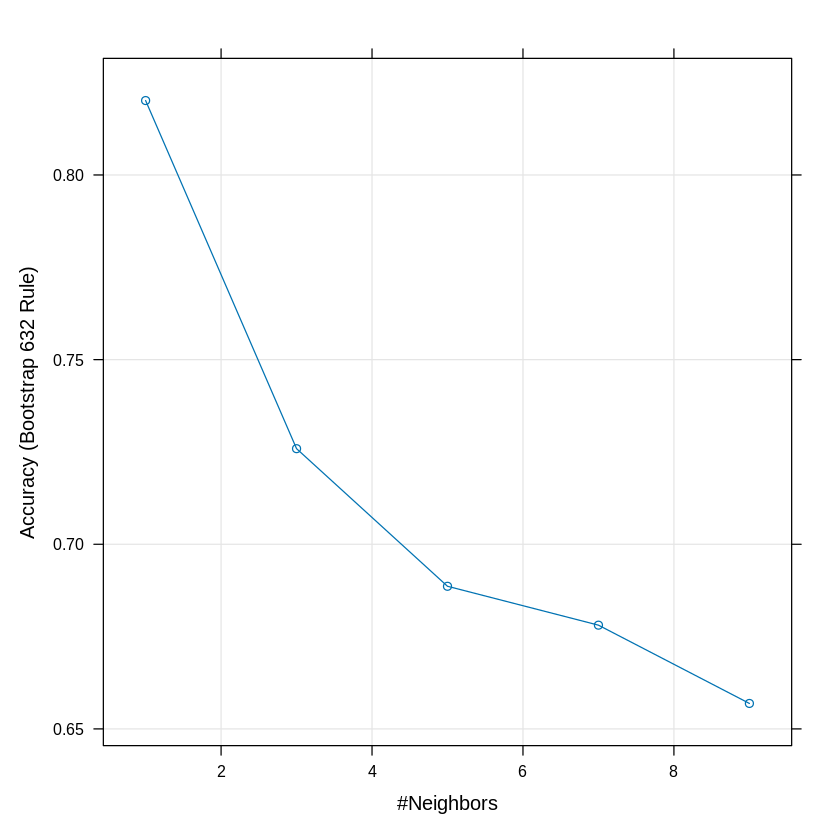

In [33]:
set.seed(1234)
trainIndex<-createDataPartition(glass$Type,p=.67,list=FALSE,times=1)
glassTrain<-glass[trainIndex,]
glassTest<-glass[-trainIndex,]
KNNmodel.tuned = train(glassTrain[,1:9], glassTrain$Type,
                       method="knn",
                       trControl = trainControl(method="boot632"),
                       tuneGrid = expand.grid(k = c(1,3,5,7,9)))
KNNmodel.tuned
plot(KNNmodel.tuned)

# If we tune on all the data
KNNmodel.tuned = train(glass[,1:9], glass$Type,
                       method="knn",
                       trControl = trainControl(method="boot632"),
                       tuneGrid = expand.grid(k = c(1,3,5,7,9)))
KNNmodel.tuned
plot(KNNmodel.tuned)

# This is better, but is
KNNmodel.tuned$results[1,2]

a good estimate of the accuracy?

Here I am very suspicious of the 0.632 bootstrap. Why?

Let's look at the confusion matrix for the TRAINING ERROR:

In [34]:
table(predict(KNNmodel.tuned,glass,type="raw"),glass$Type)

                        
                         'build wind float' 'build wind non-float'
  'build wind float'                     70                      0
  'build wind non-float'                  0                     76
  'vehic wind float'                      0                      0
  containers                              0                      0
  headlamps                               0                      0
  tableware                               0                      0
                        
                         'vehic wind float' containers headlamps tableware
  'build wind float'                      0          0         0         0
  'build wind non-float'                  0          0         0         0
  'vehic wind float'                     17          0         0         0
  containers                              0         13         0         0
  headlamps                               0          0        29         0
  tableware                    

All the predictions are on the diagonal, that is, the training error is zero

Remember that the 0.632 is a weighted average

 0.632 e_{boot} + 0.368 e_{train}

Since e_{train} = 0, this estimate will be very optimistic

Let's try using cross-validation instead

k-Nearest Neighbors 

214 samples
  9 predictor
  6 classes: ''build wind float'', ''build wind non-float'', ''vehic wind float'', 'containers', 'headlamps', 'tableware' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 193, 193, 193, 191, 193, 192, ... 
Resampling results across tuning parameters:

  k  Accuracy   Kappa    
  1  0.7292189  0.6320140
  3  0.6725061  0.5549466
  5  0.6551120  0.5249126
  7  0.6546979  0.5232885
  9  0.6230774  0.4749224

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 1.

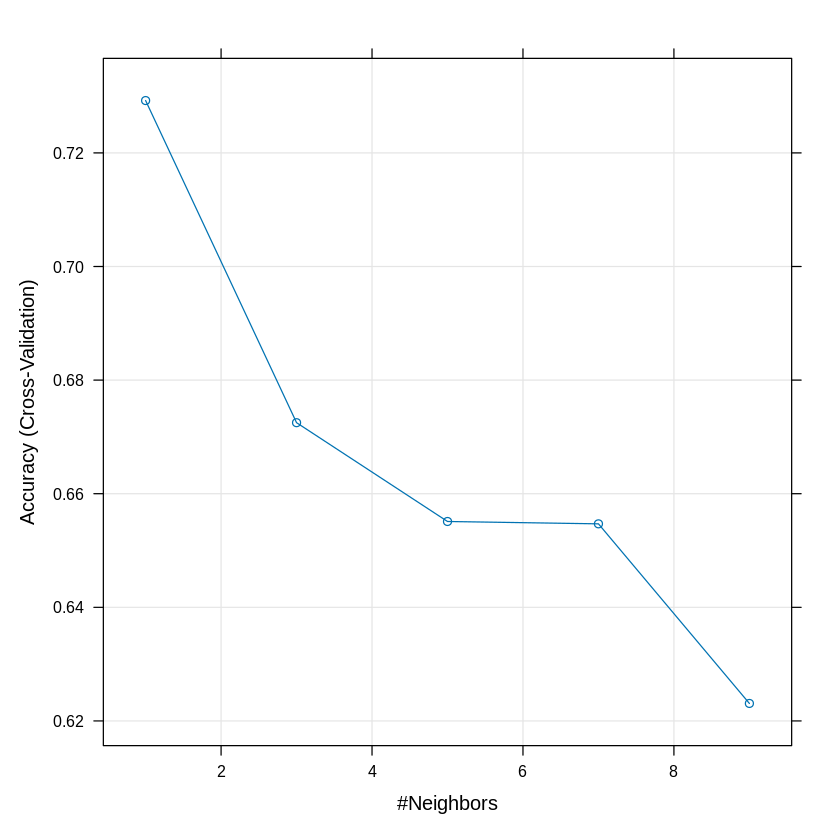

In [35]:
KNNmodel.tuned = train(glass[,1:9], glass$Type,
                       method="knn",
                       trControl = trainControl(method="cv"),
                       tuneGrid = expand.grid(k = c(1,3,5,7,9)))
KNNmodel.tuned
plot(KNNmodel.tuned)

Note that the cross-validation estimate of the error is much lower (and probably more reasonable).

Conclusion regarding error estimation methods when using KNN to learn from the glass data:

1) I know that I want to use the whole data to train because of high variance so I want to use a resampling approach to estimate the error. The candidates are 0.632-bootstrap and cross-validation

2) Since the optimal parameter is k=1, and this model will have zero training error, 0.632-bootstrap is not a great option. I hence conclude that I want to train on all the data and use cross-valdiation to estimate the error.

3) To fine-tune this conclusion, I would next consider how many folds I should use (e.g., 5-fold CV, 10-fold CV, LOOCV)


Small Side Note: I keep saying that ggplot2 is better than plot. Here's a little example. There will be much more convincing examples later.



Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the caret package.
  Please report the issue at <https://github.com/topepo/caret/issues>.”


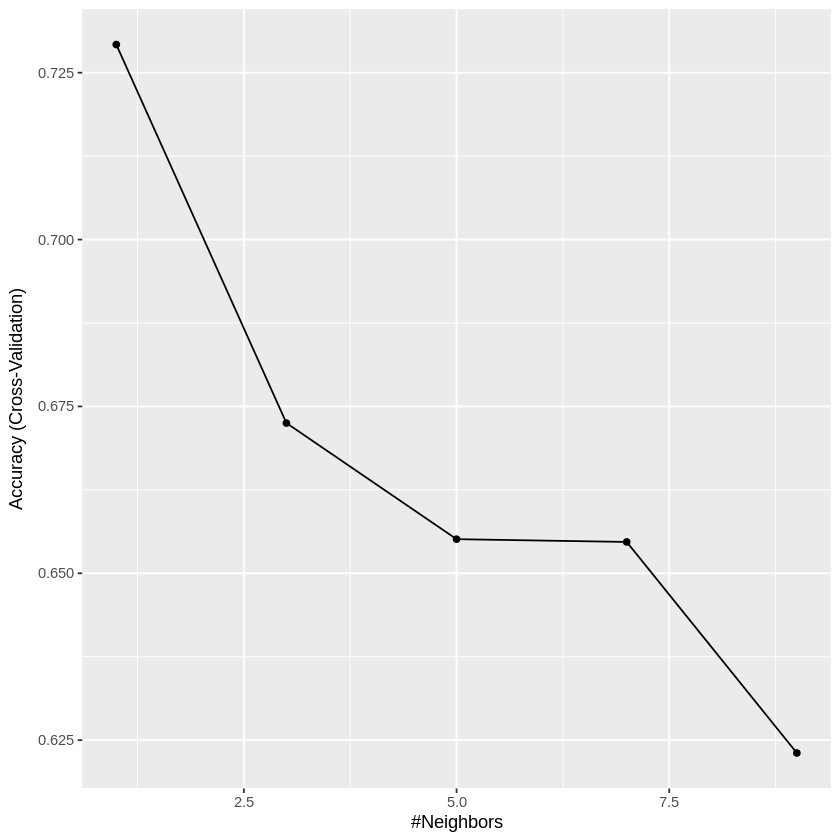

In [36]:
ggplot(KNNmodel.tuned)

## **Boosting/Bagging for Glass Data (lecture notes example)**

 This code generates the plots at the end of the lecture notes on ensemble models. First run it with n = 50 iterations, and then try to increase the iterations to, say, n = 500.

In [37]:
n = 50

Set up a for-loop to get results for all 3 samples and both ensemble models.

In [38]:
train.error.boosted = matrix(nrow=3,ncol=n)
test.error.boosted = matrix(nrow=3,ncol=n)
train.error.bagged = matrix(nrow=3,ncol=n)
test.error.bagged = matrix(nrow=3,ncol=n)
for(i in 1:3){
  set.seed(as.integer(i*2+3))
  train = sample(1:length(glass$Type),
                 size = as.integer(length(glass$Type)*0.8),
                 replace =FALSE)
  bagged.trees = bagging(Type~.,
                         data = glass[train,],
                         mfinal = n,
                         control=rpart.control(cp = 0.001))
  boosted.trees = boosting(Type~.,
                           data = glass[train,],
                           mfinal = n,
                           control=rpart.control(cp = 0.001))

  train.error.bagged[i,]=as.vector(errorevol(bagged.trees,glass[train,])$error)
  test.error.bagged[i,]=as.vector(errorevol(bagged.trees,glass[-train,])$error)
  train.error.boosted[i,]=as.vector(errorevol(boosted.trees,glass[train,])$error)
  test.error.boosted[i,]=as.vector(errorevol(boosted.trees,glass[-train,])$error)
}


I prefer to do my own plotting so that I can get exactly what I want to show! We can use the basic plot function (here) or we can use ggplot2 (better - later)

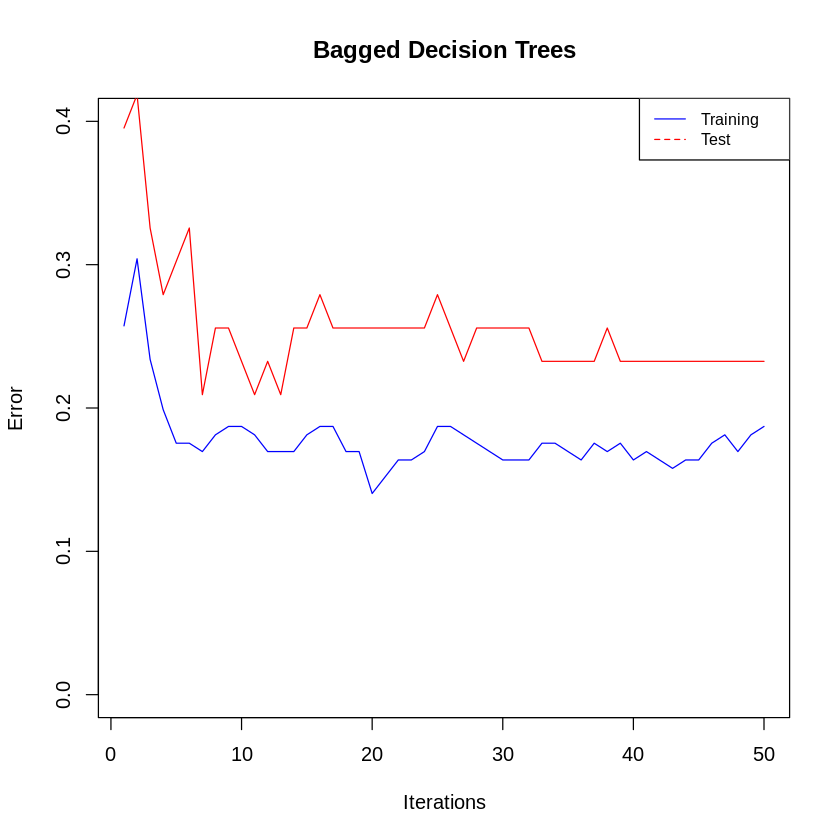

In [42]:
plot(1:n,train.error.bagged[3,],
     ylim=c(0,0.4),
     type="l",
     col="blue",
     xlab = "Iterations",
     ylab = "Error",
     main="Bagged Decision Trees")
lines(1:n,test.error.bagged[3,],col="red") # This adds to the plot
                                           # we already created
legend("topright", legend=c("Training", "Test"),
       col=c("blue", "red"), lty=1:2, cex=0.8)


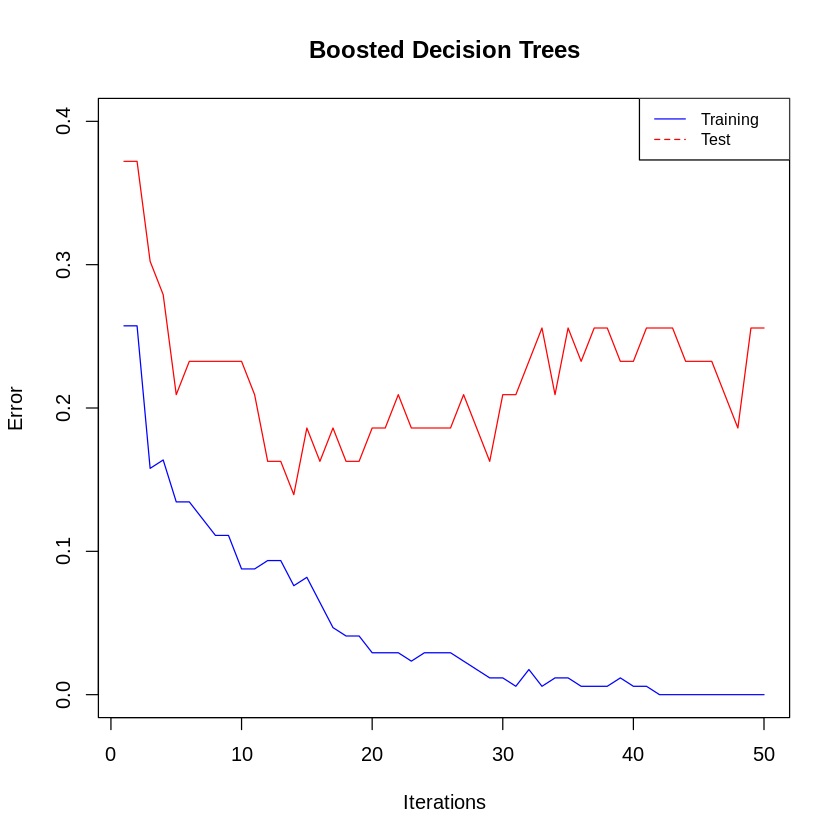

In [43]:
plot(1:n,train.error.boosted[1,],
     ylim=c(0,0.4),
     type="l",
     col="blue",
     xlab = "Iterations",
     ylab = "Error",
     main="Boosted Decision Trees")
lines(1:n,test.error.boosted[2,],col="red")
legend("topright", legend=c("Training", "Test"),
       col=c("blue", "red"), lty=1:2, cex=0.8)

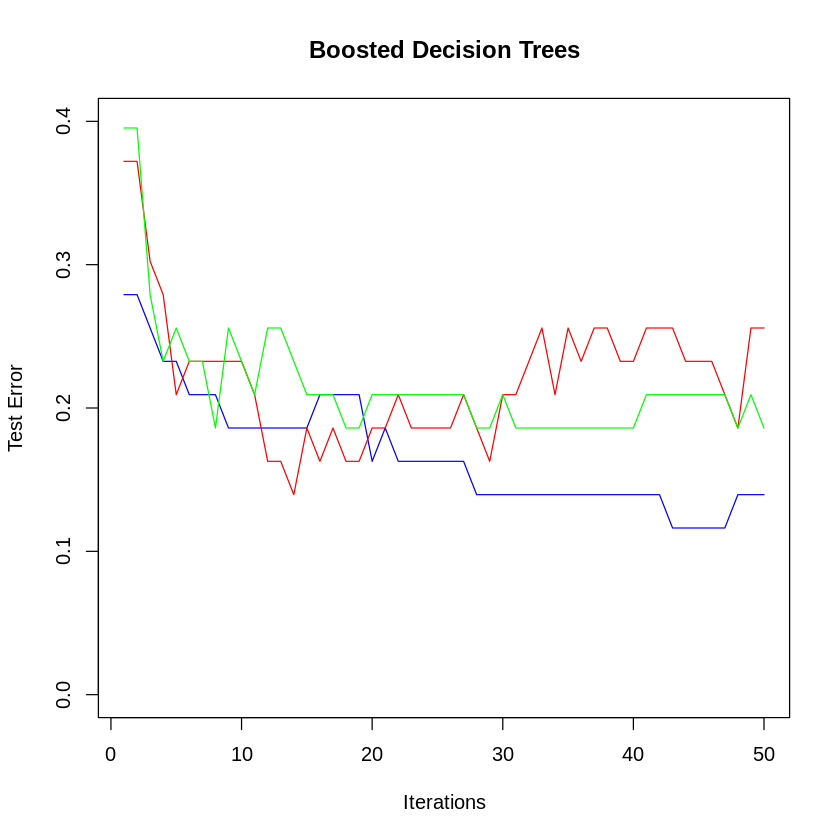

In [44]:
plot(1:n,test.error.boosted[1,],
     ylim=c(0,0.4),
     type="l",
     col="blue",
     xlab = "Iterations",
     ylab = "Test Error",
     main="Boosted Decision Trees")
lines(1:n,test.error.boosted[2,],col="red")
lines(1:n,test.error.boosted[3,],col="green")

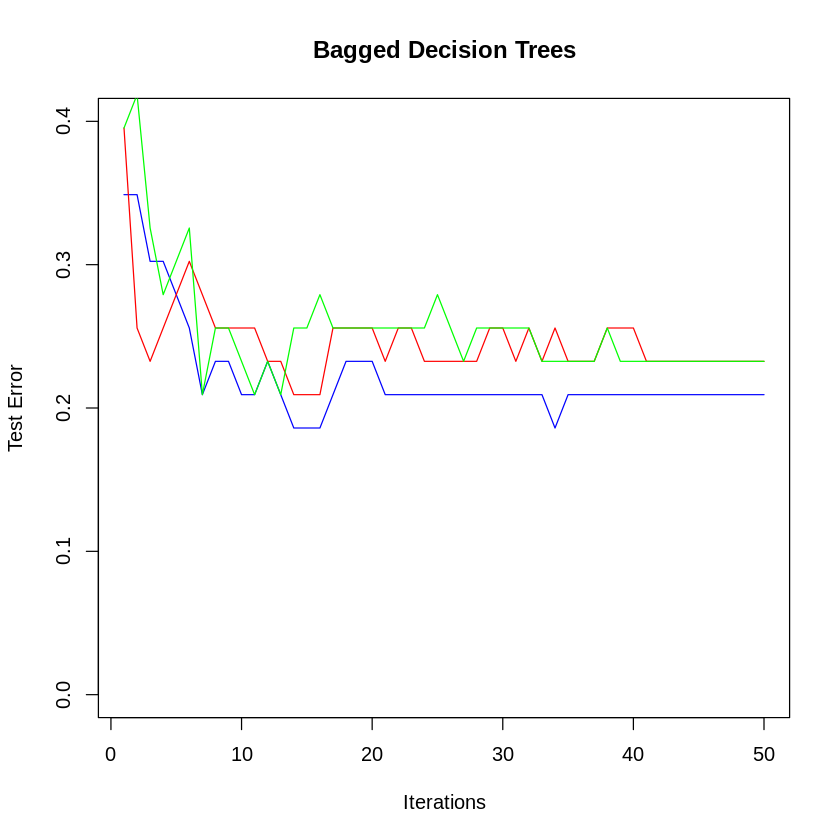

In [45]:
plot(1:n,test.error.bagged[1,],
     ylim=c(0,0.4),
     type="l",
     col="blue",
     xlab = "Iterations",
     ylab = "Test Error",
     main="Bagged Decision Trees")
lines(1:n,test.error.bagged[2,],col="red")
lines(1:n,test.error.bagged[3,],col="green")

Note on advanced ensemble models

There are better packages for boosting in R. You can check out "xgboost" as we will look at this specific implementation later.

This packages has a lot of options for what is called regularization, which we will discuss in detail at that time.

For better bagging we will go to the random forest. It is not pure bagging but has a clever improvement that turns out to be quite substantial.